iter 001 | sample t=0.355 | C_samp=9.272e-01 | mean_cost~5.799e+02


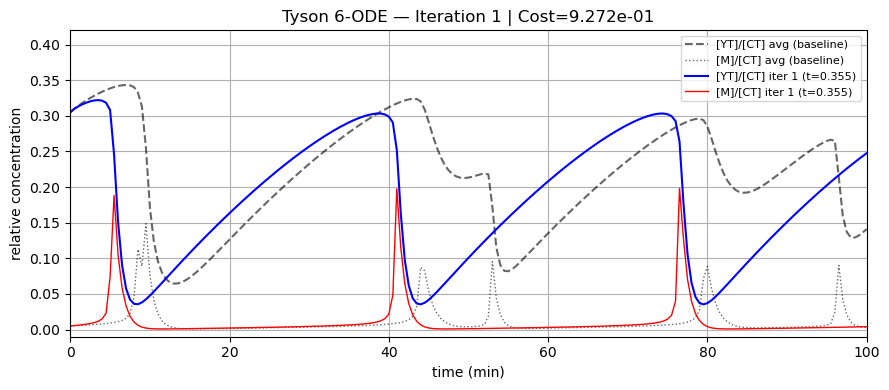

iter 005 | sample t=0.407 | C_samp=1.069e+03 | mean_cost~5.441e+02


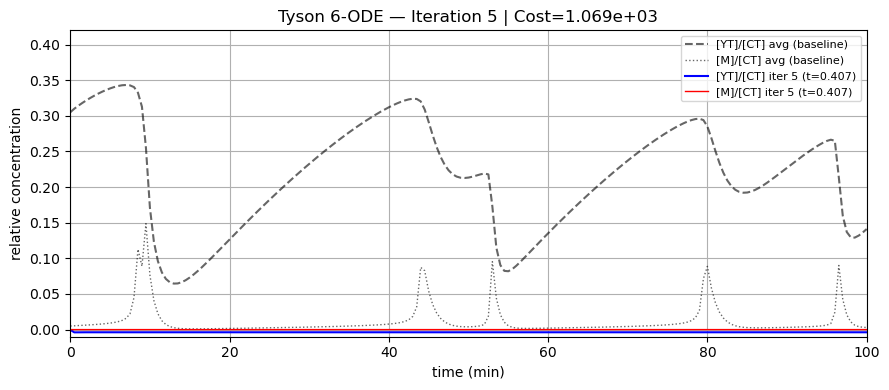

iter 010 | sample t=0.677 | C_samp=8.880e+02 | mean_cost~5.420e+02


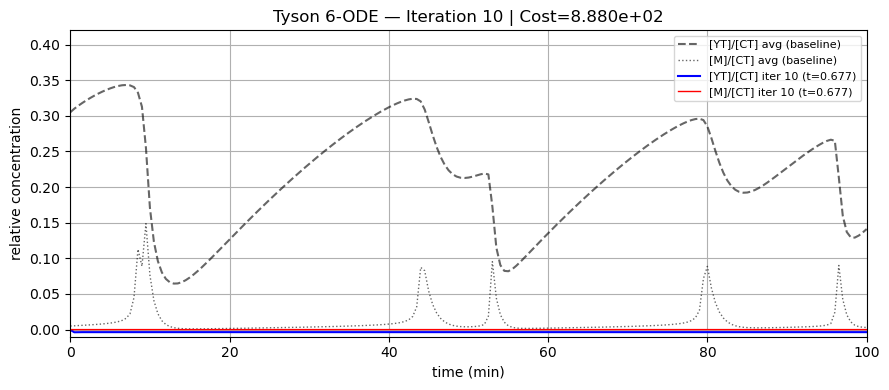

iter 015 | sample t=0.588 | C_samp=1.073e+03 | mean_cost~5.396e+02


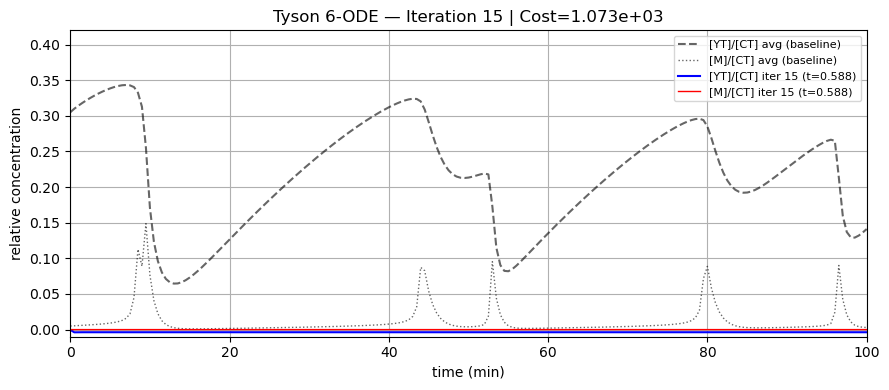

iter 020 | sample t=0.631 | C_samp=9.916e+02 | mean_cost~5.372e+02


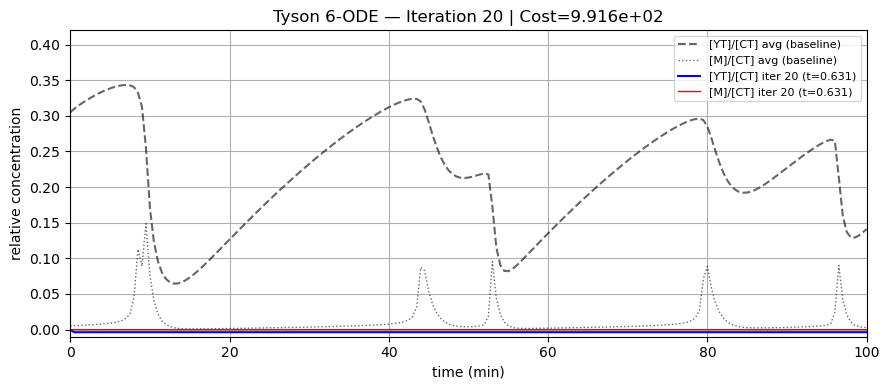

iter 025 | sample t=0.572 | C_samp=2.033e+04 | mean_cost~9.678e+03


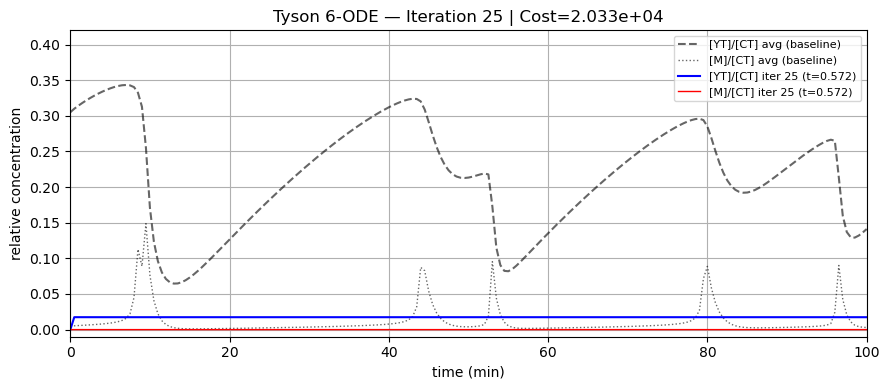

iter 030 | sample t=0.041 | C_samp=6.946e+02 | mean_cost~9.645e+03


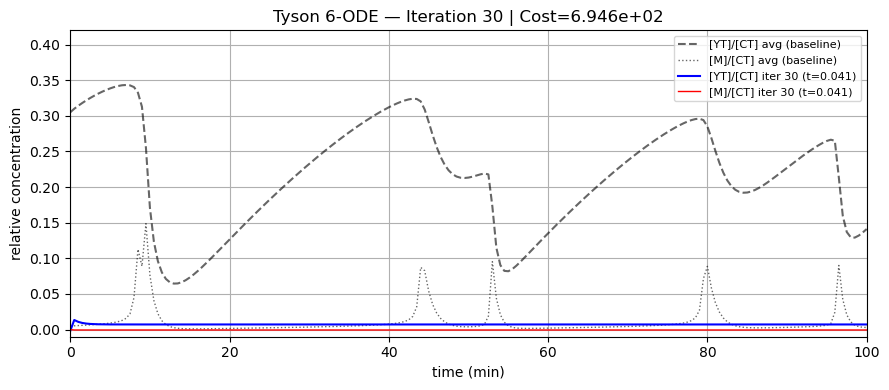

iter 035 | sample t=0.863 | C_samp=4.679e+03 | mean_cost~9.606e+03


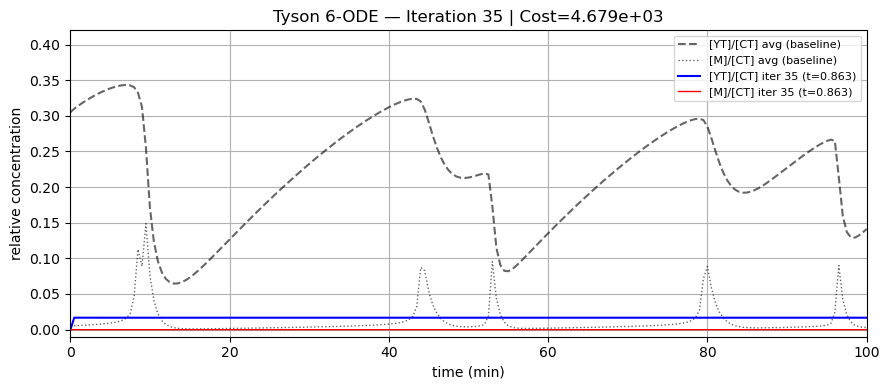

iter 040 | sample t=0.256 | C_samp=1.219e+04 | mean_cost~9.592e+03


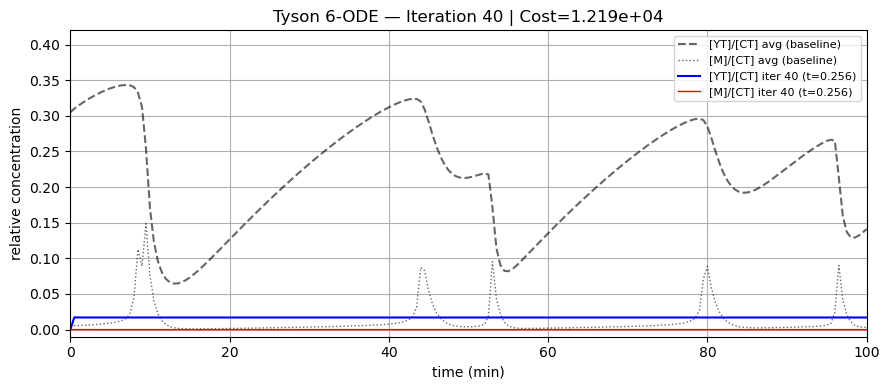

iter 045 | sample t=0.566 | C_samp=2.022e+04 | mean_cost~9.563e+03


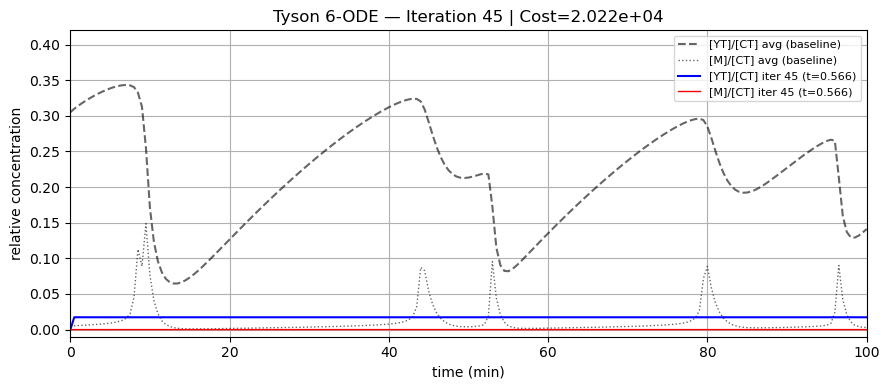

iter 050 | sample t=0.048 | C_samp=8.457e+02 | mean_cost~9.535e+03


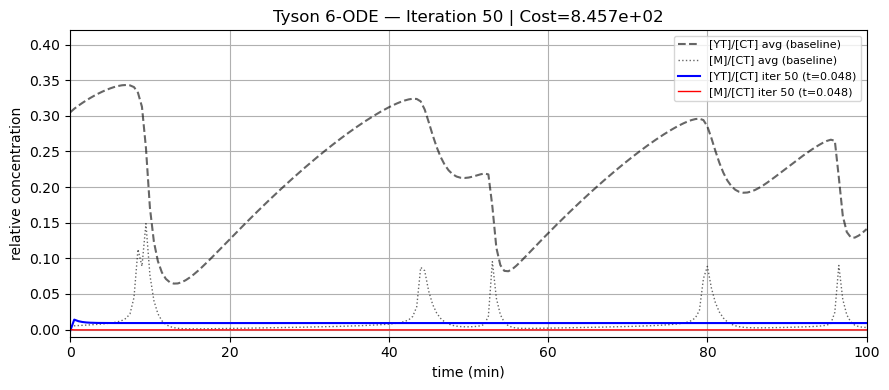

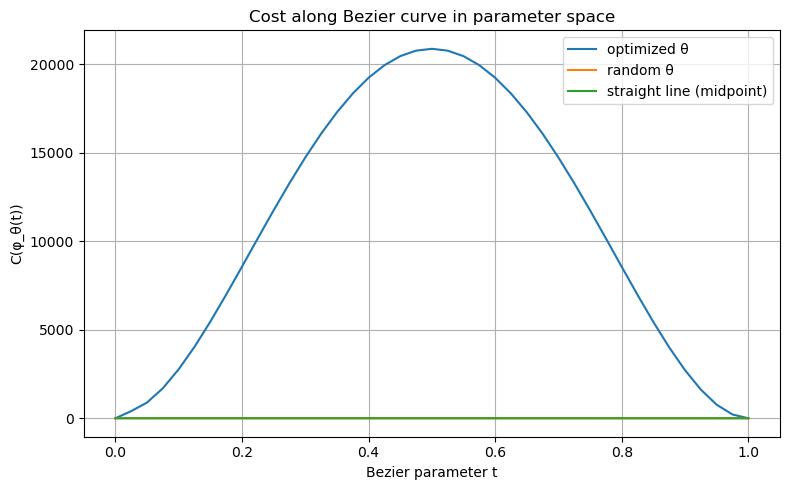

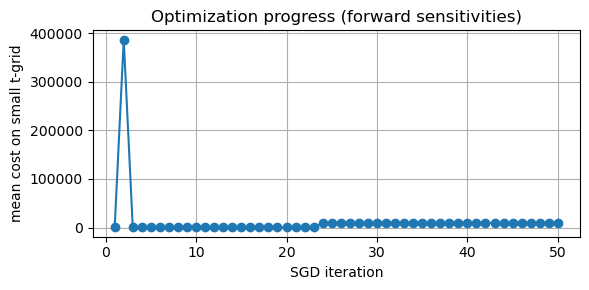

Final optimized theta:
 [ 2.72828173e+02  1.53908899e+04  2.12141306e+02  4.22422252e+02
  2.43163865e+03 -8.76214176e+01  2.33277568e+02  6.42576784e+00
  8.91968084e+01  7.25529725e+01 -2.30749286e+03]


In [ ]:
# Forward sensitivities for a stiff ODE (BDF) + Bezier control optimization (PyTorch)
# ------------------------------------------------------------------------------
# - Integrates X(t; w) and sensitivities S(t) = dX/dw by solving the augmented ODE:
#       dX/dt = f(X, w)
#       dS/dt = (∂f/∂X) · S + (∂f/∂w)
# - Uses explicit analytical Jacobians Jx and Jw (no nested autograd).
# - Optimizes the quadratic Bezier control point theta with SGD over t ~ U(0,1).
# - Plots cost profiles along t for: optimized theta, random theta, and straight line.
# ------------------------------------------------------------------------------

import math
import numpy as np
import torch
from torch import tensor
from torchdiffeq import odeint
import matplotlib.pyplot as plt

# -------------------------
# Settings (tune as needed)
# -------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype  = torch.float64
torch.set_default_dtype(dtype)

T_FINAL   = 100.0
N_TSTEPS  = 201               # time grid for integration & trapezoid
RTOL      = 1e-6
ATOL      = 1e-8
EPS_CT    = 1e-12             # to avoid divide-by-zero in CT
SEED      = 0
MAX_ITERS = 50                # SGD iterations on theta
LR        = 1e-3              # learning rate
N_PROFILE = 41                # points for plotting cost vs t
PLOT_EVERY = 5                # plot trajectories every N iterations

# Set random seed for reproducibility
torch.manual_seed(SEED)

# -------------------------
# Model (your dynamics)
# -------------------------
def f_torch(state, p_vec):
    # state: tensor length 6  -> [C2, CP, pM, M, Y, YP]
    C2, CP, pM, M, Y, YP = state

    k1_aa_over_CT = p_vec[0]
    k2            = p_vec[1]
    k3_CT         = p_vec[2]
    k4            = p_vec[3]
    k4prime       = p_vec[4]
    k5_minusP     = p_vec[5]
    k6            = p_vec[6]
    k7            = p_vec[7]
    k8_minusP     = p_vec[8]
    k9            = p_vec[9]
    CT            = p_vec[10]

    denomC = CT + EPS_CT
    k3 = k3_CT / denomC
    k1 = k1_aa_over_CT * CT

    # F_M
    FM = k4prime + k4 * (M / denomC)**2

    # rates
    dC2 = k6 * M - k8_minusP * C2 + k9 * CP
    dCP = -k3 * CP * Y + k8_minusP * C2 - k9 * CP
    dpM = k3 * CP * Y - pM * FM + k5_minusP * M
    dM  = pM * FM - k5_minusP * M - k6 * M
    dY  = k1 - k2 * Y - k3 * CP * Y
    dYP = k6 * M - k7 * YP

    return torch.stack([dC2, dCP, dpM, dM, dY, dYP])

# -------------------------
# Analytical Jacobians
# -------------------------
def Jx_f(state, p_vec):
    """Jacobian wrt state: Jx = ∂f/∂X  (6x6)"""
    C2, CP, pM, M, Y, YP = state
    k1_aa_over_CT, k2, k3_CT, k4, k4prime, k5m, k6, k7, k8m, k9, CT = p_vec

    denomC = CT + EPS_CT
    k3 = k3_CT / denomC
    FM = k4prime + k4 * (M / denomC)**2
    dFM_dM = 2.0 * k4 * M / (denomC**2)

    J = torch.zeros((6,6), dtype=dtype, device=device)

    # dC2
    J[0,0] = -k8m
    J[0,1] =  k9
    J[0,3] =  k6

    # dCP
    J[1,0] =  k8m
    J[1,1] = -k3*Y - k9
    J[1,4] = -k3*CP

    # dpM
    J[2,1] =  k3*Y
    J[2,2] = -FM
    J[2,3] = -pM * dFM_dM + k5m
    J[2,4] =  k3*CP

    # dM
    J[3,2] =  FM
    J[3,3] =  pM * dFM_dM - k5m - k6

    # dY
    J[4,1] = -k3*Y
    J[4,4] = -k2 - k3*CP

    # dYP
    J[5,3] =  k6
    J[5,5] = -k7

    return J

def Jw_f(state, p_vec):
    """Jacobian wrt parameters: Jw = ∂f/∂w  (6x11)"""
    C2, CP, pM, M, Y, YP = state
    k1aa, k2, k3_CT, k4, k4prime, k5m, k6, k7, k8m, k9, CT = p_vec

    denomC = CT + EPS_CT
    k3 = k3_CT / denomC
    FM = k4prime + k4 * (M / denomC)**2

    # helpful partials
    dk3_d_k3CT = 1.0 / denomC
    dk3_d_CT   = -k3_CT / (denomC**2)          # = -k3 / denomC
    dk1_d_k1aa = CT
    dk1_d_CT   = k1aa
    dFM_d_k4   = (M / denomC)**2
    dFM_d_k4p  = 1.0
    dFM_d_CT   = -2.0 * k4 * (M**2) / (denomC**3)

    Jw = torch.zeros((6,11), dtype=dtype, device=device)

    # param 0: k1_aa_over_CT
    Jw[4,0] = dk1_d_k1aa                     # only dY

    # param 1: k2
    Jw[4,1] = -Y

    # param 2: k3_CT
    Jw[1,2] = -(CP*Y) * dk3_d_k3CT           # dCP
    Jw[2,2] =  (CP*Y) * dk3_d_k3CT           # dpM
    Jw[4,2] = -(CP*Y) * dk3_d_k3CT           # dY

    # param 3: k4 (via FM)
    Jw[2,3] = -pM * dFM_d_k4                 # dpM
    Jw[3,3] =  pM * dFM_d_k4                 # dM

    # param 4: k4prime
    Jw[2,4] = -pM
    Jw[3,4] =  pM

    # param 5: k5_minusP
    Jw[2,5] =  M
    Jw[3,5] = -M

    # param 6: k6
    Jw[0,6] =  M
    Jw[3,6] = -M
    Jw[5,6] =  M

    # param 7: k7
    Jw[5,7] = -YP

    # param 8: k8_minusP
    Jw[0,8] = -C2
    Jw[1,8] =  C2

    # param 9: k9
    Jw[0,9] =  CP
    Jw[1,9] = -CP

    # param 10: CT  (via k1, k3, FM)
    Jw[1,10] = -(CP*Y) * dk3_d_CT
    Jw[2,10] =  (CP*Y) * dk3_d_CT - pM * dFM_d_CT
    Jw[3,10] =  pM * dFM_d_CT
    Jw[4,10] =  dk1_d_CT - (CP*Y) * dk3_d_CT

    return Jw

# -------------------------
# Problem data
# -------------------------
x0 = torch.tensor([0.9, 0.05, 0.0, 0.005, 0.3, 0.0], device=device, dtype=dtype)

v1 = torch.tensor([1.5e-02, 0.0, 2.0e+02, 1.8e+02, 1.8e-02, 0.0, 1.0, 0.6, 1.0e+02, 5.0e+01, 1.0],
                  device=device, dtype=dtype)
v2 = torch.tensor([1.16000589e-02, 0.0, 5.02761655e+02, 5.74579613e+02, 1.24596408e-02, 0.0, 1.64052318, 8.22972056, 1.0e+02, 5.0e+01, 1.0],
                  device=device, dtype=dtype)

n_x = x0.numel()
n_w = v1.numel()

ts = torch.linspace(0.0, T_FINAL, N_TSTEPS, device=device, dtype=dtype)

# -------------------------
# Solvers
# -------------------------
def solve_state(w):
    """Return X(t;w) sampled on ts (shape [N_TSTEPS, 6])."""
    func = lambda t, y: f_torch(y, w)
    X = odeint(func, x0, ts, method='scipy_solver', options={'solver': 'BDF'}, rtol=RTOL, atol=ATOL)  # [N, 6]
    return X

def solve_state_and_sensitivities(w):
    """Return X(t;w) and S(t)=dX/dw on ts.
       X shape [N,6], S shape [N,6,11]."""
    # augmented state: [X, vec(S)]
    y0 = torch.cat([x0, torch.zeros(n_x*n_w, device=device, dtype=dtype)], dim=0)

    def aug_rhs(t, y):
        X = y[:n_x]
        S = y[n_x:].view(n_x, n_w)
        fX = f_torch(X, w)
        Jx = Jx_f(X, w)
        Jw = Jw_f(X, w)
        dS = Jx @ S + Jw
        return torch.cat([fX, dS.reshape(-1)])

    Y = odeint(aug_rhs, y0, ts, method='scipy_solver', options={'solver': 'BDF'}, rtol=RTOL, atol=ATOL)  # [N, 6+6*11]
    X = Y[:, :n_x]
    S = Y[:, n_x:].view(-1, n_x, n_w)
    return X, S

# -------------------------
# Cost and gradient wrt w
# -------------------------
def trajectory_cost_and_grad_w(w, Xavg):
    """C(w) = ∫ 0.5||X(t;w)-Xavg(t)||^2 dt;  dC/dw = ∫ (X-Xavg)^T S dt."""
    X, S = solve_state_and_sensitivities(w)           # [N,6], [N,6,11]
    diff = X - Xavg                                   # [N,6]
    integrand = 0.5 * (diff**2).sum(dim=1)            # [N]
    C = torch.trapz(integrand, ts)

    # (X-Xavg)^T @ S -> [N, 11]
    # diff[k]: [6], S[k]: [6,11]
    integrand_g = torch.einsum('ni, nij -> nj', diff, S)
    dC_dw = torch.trapz(integrand_g, ts, dim=0)       # [11]
    return C, dC_dw

# -------------------------
# Bezier helpers
# -------------------------
def phi_theta(theta, t_scalar):
    t = torch.as_tensor(t_scalar, dtype=dtype, device=device)
    return (1.0 - t)**2 * v1 + 2.0*t*(1.0 - t)*theta + t**2 * v2

def dphi_dtheta_scalar(t_scalar):
    t = torch.as_tensor(t_scalar, dtype=dtype, device=device)
    return 2.0 * t * (1.0 - t)                        # scalar multiplier on I

# -------------------------
# Helper function to compute YT_rel and M_rel from trajectory
# -------------------------
def compute_tyson_observables(X, CT):
    """Given trajectory X [N,6] and CT value, return YT_rel and M_rel."""
    # X columns: [C2, CP, pM, M, Y, YP]
    C2, CP, pM, M, Y, YP = X[:, 0], X[:, 1], X[:, 2], X[:, 3], X[:, 4], X[:, 5]
    YT = Y + YP + pM + M
    YT_rel = YT / (CT + EPS_CT)
    M_rel = M / (CT + EPS_CT)
    return YT_rel, M_rel

# -------------------------
# Prepare target (Xavg from v1, v2)
# -------------------------
with torch.no_grad():
    X1 = solve_state(v1)        # [N,6]
    X2 = solve_state(v2)        # [N,6]
    WEIGHT = 1
    Xavg = (1-WEIGHT)*X1 + WEIGHT*X2 
         # [N,6]
    
    # Compute baseline observables for plotting
    CT_avg = (1-WEIGHT)*v1[10] + WEIGHT*v2[10]
    YT_avg, M_avg = compute_tyson_observables(Xavg, CT_avg)

# -------------------------
# Optimize theta (SGD on forward-sensitivity gradient)
# -------------------------
torch.manual_seed(SEED)
theta_mid = 0.5 * (v1 + v2)
theta     = (theta_mid + 0.2 * (v2 - v1) * torch.randn_like(v1)).clone()

history = []

for it in range(1, MAX_ITERS+1):
    # sample t ~ U(0,1)
    t_samp = torch.rand(()).item()
    w_samp = phi_theta(theta, t_samp)

    # forward sensitivities for dC/dw
    C_samp, dC_dw = trajectory_cost_and_grad_w(w_samp, Xavg)

    # chain rule: dL/dtheta = dC/dw * dphi/dtheta
    mult = dphi_dtheta_scalar(t_samp)
    dL_dtheta = dC_dw * mult

    # gradient step
    with torch.no_grad():
        theta -= LR * dL_dtheta

    # (optional) track mean cost on a small grid for monitoring
    with torch.no_grad():
        t_eval = torch.linspace(0, 1, 7, device=device, dtype=dtype)
        costs = []
        for tt in t_eval:
            Ctt, _ = trajectory_cost_and_grad_w(phi_theta(theta, float(tt)), Xavg)
            costs.append(Ctt.item())
        history.append(float(np.mean(costs)))
        
        # Print every PLOT_EVERY iterations
        if it % PLOT_EVERY == 0 or it == 1:
            print(f"iter {it:03d} | sample t={t_samp:.3f} | C_samp={C_samp.item():.3e} | mean_cost~{history[-1]:.3e}")
            print(f"  theta = {theta.cpu().numpy()}")
        
        # Plot trajectories every PLOT_EVERY iterations
        if it % PLOT_EVERY == 0 or it == 1:
            X_samp = solve_state(w_samp)
            CT_samp = w_samp[10].item()
            YT_samp, M_samp = compute_tyson_observables(X_samp, CT_samp)
            
            t_np = ts.cpu().numpy()
            plt.figure(figsize=(9, 4))
            # Baseline (average)
            plt.plot(t_np, YT_avg.cpu().numpy(), 'k--', lw=1.5, alpha=0.6, label='[YT]/[CT] avg (baseline)')
            plt.plot(t_np, M_avg.cpu().numpy(), 'k:', lw=1.0, alpha=0.6, label='[M]/[CT] avg (baseline)')
            # Sampled point on Bezier curve
            plt.plot(t_np, YT_samp.cpu().numpy(), 'b-', lw=1.5, label=f'[YT]/[CT] iter {it} (t={t_samp:.3f})')
            plt.plot(t_np, M_samp.cpu().numpy(), 'r-', lw=1.0, label=f'[M]/[CT] iter {it} (t={t_samp:.3f})')
            
            plt.xlim(0, 100)
            plt.ylim(-0.01, 0.42)
            plt.xlabel('time (min)')
            plt.ylabel('relative concentration')
            plt.title(f'Tyson 6-ODE — Iteration {it} | Cost={C_samp.item():.3e}')
            plt.legend(fontsize=8)
            plt.grid(True)
            plt.tight_layout()
            plt.show()

# -------------------------
# Compare cost profiles along t
# -------------------------
def cost_along_curve(theta_ctrl, t_grid):
    vals = []
    with torch.no_grad():
        for tt in t_grid:
            Ctt, _ = trajectory_cost_and_grad_w(phi_theta(theta_ctrl, float(tt)), Xavg)
            vals.append(Ctt.item())
    return np.array(vals)

t_plot = np.linspace(0.0, 1.0, N_PROFILE)
theta_opt  = theta.detach().clone()
torch.manual_seed(SEED + 1)  # Different seed for random comparison
theta_rand = (theta_mid + 0.2 * (v2 - v1) * torch.randn_like(v1)).clone()
theta_line = theta_mid.clone()

cost_opt  = cost_along_curve(theta_opt,  t_plot)
cost_rand = cost_along_curve(theta_rand, t_plot)
cost_line = cost_along_curve(theta_line, t_plot)

# -------------------------
# Plots
# -------------------------
plt.figure(figsize=(8,5))
plt.plot(t_plot, cost_opt,  label='optimized θ')
plt.plot(t_plot, cost_rand, label='random θ')
plt.plot(t_plot, cost_line, label='straight line (midpoint)')
plt.xlabel('Bezier parameter t')
plt.ylabel('C(φ_θ(t))')
plt.title('Cost along Bezier curve in parameter space')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3))
plt.plot(np.arange(1, len(history)+1), history, '-o')
plt.xlabel('SGD iteration')
plt.ylabel('mean cost on small t-grid')
plt.title('Optimization progress (forward sensitivities)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Print final theta if you want to save it
print("Final optimized theta:\n", theta_opt.cpu().numpy())

In [ ]:
# ------------------------------------------------------------
# Jacobian checks for f_torch: analytical vs. autodiff
# ------------------------------------------------------------
# Requires: torch, (optional) torchdiffeq if you want the along-trajectory check.
# This file does NOT execute anything by default. Uncomment the example
# calls at the bottom to run the checks.
# ------------------------------------------------------------
import math
import numpy as np
import torch

# Optional (only needed for along-trajectory check)
try:
    from torchdiffeq import odeint
    HAS_TORCHDIFFEQ = True
except Exception:
    HAS_TORCHDIFFEQ = False

# -------------------------
# Global settings
# -------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype  = torch.float64
torch.set_default_dtype(dtype)

RTOL, ATOL = 1e-6, 1e-8
T_FINAL    = 10.0
N_TSTEPS   = 201
EPS_CT     = 1e-12

# -------------------------
# Dynamics (as provided)
# -------------------------
def f_torch(state, p_vec):
    # state: tensor length 6 -> [C2, CP, pM, M, Y, YP]
    C2, CP, pM, M, Y, YP = state

    k1_aa_over_CT = p_vec[0]
    k2            = p_vec[1]
    k3_CT         = p_vec[2]
    k4            = p_vec[3]
    k4prime       = p_vec[4]
    k5_minusP     = p_vec[5]
    k6            = p_vec[6]
    k7            = p_vec[7]
    k8_minusP     = p_vec[8]
    k9            = p_vec[9]
    CT            = p_vec[10]

    denomC = CT + EPS_CT
    k3 = k3_CT / denomC
    k1 = k1_aa_over_CT * CT

    FM = k4prime + k4 * (M / denomC)**2

    dC2 = k6 * M - k8_minusP * C2 + k9 * CP
    dCP = -k3 * CP * Y + k8_minusP * C2 - k9 * CP
    dpM = k3 * CP * Y - pM * FM + k5_minusP * M
    dM  = pM * FM - k5_minusP * M - k6 * M
    dY  = k1 - k2 * Y - k3 * CP * Y
    dYP = k6 * M - k7 * YP

    return torch.stack([dC2, dCP, dpM, dM, dY, dYP])

# -------------------------
# Analytical Jacobians
# -------------------------
def Jx_f(state, p_vec):
    """Jacobian wrt state: Jx = ∂f/∂X  (6x6)"""
    C2, CP, pM, M, Y, YP = state
    k1_aa_over_CT, k2, k3_CT, k4, k4prime, k5m, k6, k7, k8m, k9, CT = p_vec

    denomC = CT + EPS_CT
    k3 = k3_CT / denomC
    FM = k4prime + k4 * (M / denomC)**2
    dFM_dM = 2.0 * k4 * M / (denomC**2)

    J = torch.zeros((6,6), dtype=dtype, device=state.device)

    # dC2
    J[0,0] = -k8m
    J[0,1] =  k9
    J[0,3] =  k6

    # dCP
    J[1,0] =  k8m
    J[1,1] = -k3*Y - k9
    J[1,4] = -k3*CP

    # dpM
    J[2,1] =  k3*Y
    J[2,2] = -FM
    J[2,3] = -pM * dFM_dM + k5m
    J[2,4] =  k3*CP

    # dM
    J[3,2] =  FM
    J[3,3] =  pM * dFM_dM - k5m - k6

    # dY
    J[4,1] = -k3*Y
    J[4,4] = -k2 - k3*CP

    # dYP
    J[5,3] =  k6
    J[5,5] = -k7

    return J

def Jw_f(state, p_vec):
    """Jacobian wrt parameters: Jw = ∂f/∂w  (6x11)"""
    C2, CP, pM, M, Y, YP = state
    k1aa, k2, k3_CT, k4, k4prime, k5m, k6, k7, k8m, k9, CT = p_vec

    denomC = CT + EPS_CT
    k3 = k3_CT / denomC
    FM = k4prime + k4 * (M / denomC)**2

    # partials
    dk3_d_k3CT = 1.0 / denomC
    dk3_d_CT   = -k3_CT / (denomC**2)      # = -k3 / denomC
    dk1_d_k1aa = CT
    dk1_d_CT   = k1aa
    dFM_d_k4   = (M / denomC)**2
    dFM_d_k4p  = 1.0
    dFM_d_CT   = -2.0 * k4 * (M**2) / (denomC**3)

    Jw = torch.zeros((6,11), dtype=dtype, device=state.device)

    # k1_aa_over_CT
    Jw[4,0] = dk1_d_k1aa

    # k2
    Jw[4,1] = -Y

    # k3_CT
    Jw[1,2] = -(CP*Y) * dk3_d_k3CT
    Jw[2,2] =  (CP*Y) * dk3_d_k3CT
    Jw[4,2] = -(CP*Y) * dk3_d_k3CT

    # k4
    Jw[2,3] = -pM * dFM_d_k4
    Jw[3,3] =  pM * dFM_d_k4

    # k4prime
    Jw[2,4] = -pM
    Jw[3,4] =  pM

    # k5_minusP
    Jw[2,5] =  M
    Jw[3,5] = -M

    # k6
    Jw[0,6] =  M
    Jw[3,6] = -M
    Jw[5,6] =  M

    # k7
    Jw[5,7] = -YP

    # k8_minusP
    Jw[0,8] = -C2
    Jw[1,8] =  C2

    # k9
    Jw[0,9] =  CP
    Jw[1,9] = -CP

    # CT (via k1, k3, FM)
    Jw[1,10] = -(CP*Y) * dk3_d_CT
    Jw[2,10] =  (CP*Y) * dk3_d_CT - pM * dFM_d_CT
    Jw[3,10] =  pM * dFM_d_CT
    Jw[4,10] =  dk1_d_CT - (CP*Y) * dk3_d_CT

    return Jw

# -------------------------
# Problem data (x0, v1, v2) if you want along-trajectory check
# -------------------------
x0 = torch.tensor([0.9, 0.05, 0.0, 0.005, 0.3, 0.0], device=device, dtype=dtype)
v1 = torch.tensor([1.5e-02, 0.0, 2.0e+02, 1.8e+02, 1.8e-02, 0.0, 1.0, 0.6, 1.0e+02, 5.0e+01, 1.0],
                  device=device, dtype=dtype)
v2 = torch.tensor([1.16000589e-02, 0.0, 5.02761655e+02, 5.74579613e+02, 1.24596408e-02, 0.0, 1.64052318, 8.22972056, 1.0e+02, 5.0e+01, 1.0],
                  device=device, dtype=dtype)

# -------------------------
# Autodiff helpers
# -------------------------
def autograd_Jx(state, params):
    state_req = state.detach().clone().requires_grad_(True)
    params_c  = params.detach().clone()  # treated as constant for Jx
    # PyTorch Jacobian wrt state
    Jx = torch.autograd.functional.jacobian(lambda s: f_torch(s, params_c), state_req)
    return Jx

def autograd_Jw(state, params):
    params_req = params.detach().clone().requires_grad_(True)
    state_c    = state.detach().clone()  # treated as constant for Jw
    # PyTorch Jacobian wrt params
    Jw = torch.autograd.functional.jacobian(lambda p: f_torch(state_c, p), params_req)
    return Jw

# -------------------------
# Norms & comparison
# -------------------------
def max_abs_rel(diff, ref, eps=1e-12):
    max_abs = diff.abs().max().item()
    denom   = ref.abs().max().item()
    rel     = max_abs / (denom + eps)
    return max_abs, rel

def check_jacobians_at_point(state, params, verbose=True, tol_abs=1e-9, tol_rel=1e-7):
    """Compare analytical Jx_f/Jw_f with autodiff Jacobians at a single (state, params)."""
    with torch.no_grad():
        # ensure dtype/device
        state = state.to(device=device, dtype=dtype)
        params = params.to(device=device, dtype=dtype)

    # autodiff
    Jx_ad = autograd_Jx(state, params)
    Jw_ad = autograd_Jw(state, params)

    # analytical
    Jx_an = Jx_f(state, params)
    Jw_an = Jw_f(state, params)

    dx   = (Jx_an - Jx_ad)
    dw   = (Jw_an - Jw_ad)
    dx_abs, dx_rel = max_abs_rel(dx, Jx_ad)
    dw_abs, dw_rel = max_abs_rel(dw, Jw_ad)

    if verbose:
        print("=== Jacobian check at point ===")
        print("‖Jx_an - Jx_ad‖_max  = {:.3e}   (rel {:.3e})".format(dx_abs, dx_rel))
        print("‖Jw_an - Jw_ad‖_max  = {:.3e}   (rel {:.3e})".format(dw_abs, dw_rel))
        print(f"PASS Jx? {dx_abs < tol_abs or dx_rel < tol_rel}")
        print(f"PASS Jw? {dw_abs < tol_abs or dw_rel < tol_rel}")
    return {
        'Jx_max_abs_err': dx_abs, 'Jx_rel_err': dx_rel,
        'Jw_max_abs_err': dw_abs, 'Jw_rel_err': dw_rel,
        'Jx_an': Jx_an, 'Jx_ad': Jx_ad, 'Jw_an': Jw_an, 'Jw_ad': Jw_ad
    }

# -------------------------
# Along-trajectory check (optional)
# -------------------------
def solve_state(w, ts):
    """Integrate the stiff system with BDF and return X(ts)."""
    assert HAS_TORCHDIFFEQ, "torchdiffeq is required for trajectory-based checks."
    func = lambda t, y: f_torch(y, w)
    X = odeint(func, x0, ts, method='scipy_solver', options={'solver': 'BDF'}, rtol=RTOL, atol=ATOL)  # [N,6]
    return X

def check_along_trajectory(params, n_samples=5, verbose=True):
    """Integrate once, sample a few timepoints, and compare Jacobians there."""
    assert HAS_TORCHDIFFEQ, "torchdiffeq is required for trajectory-based checks."
    ts = torch.linspace(0.0, T_FINAL, N_TSTEPS, device=device, dtype=dtype)
    with torch.no_grad():
        Xtraj = solve_state(params, ts)

    idxs = torch.linspace(0, N_TSTEPS-1, n_samples, dtype=torch.long)
    results = []
    for i in idxs:
        state_i = Xtraj[i]
        res = check_jacobians_at_point(state_i, params, verbose=verbose)
        results.append(res)
    return results

# ------------------------------------------------------------
# EXAMPLE USAGE (uncomment what you want to run)
# ------------------------------------------------------------
# 1) Quick random point check near (x0, v1):
torch.manual_seed(0)
state_test = x0 + 0.01*torch.randn_like(x0)
params_test = v1 + 0.01*torch.randn_like(v1)
_ = check_jacobians_at_point(state_test, params_test, verbose=True)

# 2) Check at the exact initial condition (x0, v1):
_ = check_jacobians_at_point(x0, v1, verbose=True)

# 3) Along-trajectory check for v1 (requires torchdiffeq):
if HAS_TORCHDIFFEQ:
    _ = check_along_trajectory(v1, n_samples=5, verbose=True)
else:
    print("Install torchdiffeq for along-trajectory checks: pip install torchdiffeq")


=== Jacobian check at point ===
‖Jx_an - Jx_ad‖_max  = 1.388e-17   (rel 1.283e-19)
‖Jw_an - Jw_ad‖_max  = 1.735e-18   (rel 6.258e-19)
PASS Jx? True
PASS Jw? True
=== Jacobian check at point ===
‖Jx_an - Jx_ad‖_max  = 0.000e+00   (rel 0.000e+00)
‖Jw_an - Jw_ad‖_max  = 4.441e-16   (rel 1.473e-16)
PASS Jx? True
PASS Jw? True
Install torchdiffeq for along-trajectory checks: pip install torchdiffeq
